In [26]:
from pathlib import Path
import numpy as np
from glob import glob
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import pandas as pd
from itertools import product

<Axes: ylabel='Count'>

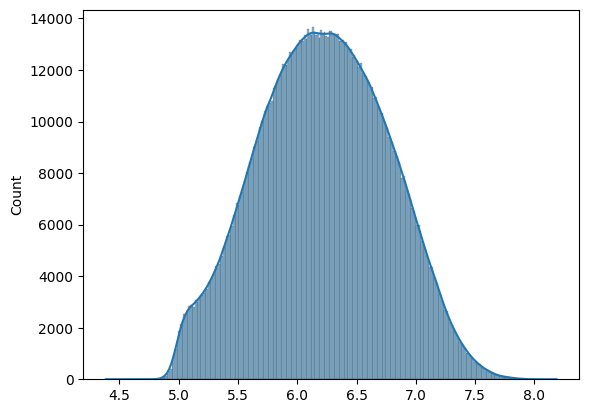

In [3]:
predictions = np.load("/app/datasets/vb-clean_ident/scf_vb2.npz")
kappa = predictions["unc"][:, 0]
sns.histplot(data=kappa, kde=True)

In [10]:
paths = np.load("/app/datasets/vb-clean_ident/paths.npy")

In [13]:
paths

array(['/app/datasets/VB1/audio/id00000/DwgYRqnQZHM/00000.wav',
       '/app/datasets/VB1/audio/id00002/rhG0yigbjsQ/00000.wav',
       '/app/datasets/VB1/audio/id00007/6L1piVZix-A/00000.wav', ...,
       '/app/datasets/VB1/audio/id61320/sBIJY8NXavo/00001.wav',
       '/app/datasets/VB1/audio/id61321/y51WNwAnhjE/00000.wav',
       '/app/datasets/VB1/audio/id61321/y51WNwAnhjE/00001.wav'],
      dtype='<U53')

## Create meta files

In [4]:
ident_ds_dir = Path("/app/datasets/vb-clean_ident")
ident_ds_dir.mkdir(exist_ok=True)

In [6]:
# there is not templates for out-of-gallery samples. They all come as single template image

In [33]:
# list protocols
protools_path = "/app/sandbox/ScriptsForVoxBlink2/data/ossi"
protools_paths = list(glob(protools_path + "/*"))

# create meta files
template_idx_shift = 10000  # shift to get unique template ids
for protocol_path, template_size in product(
    protools_paths, ["perspk1", "perspk3", "perspk5"]
):
    protocol_path = Path(protocol_path)
    ds_name = protocol_path.parts[-1] + "-" + template_size
    meta_path = ident_ds_dir / protocol_path.parts[-1] / template_size / "meta"
    meta_path.mkdir(exist_ok=True, parents=True)

    ossi_info_path = protocol_path / template_size
    gallery_ids = []
    gallery_paths = []
    with open(ossi_info_path / "gallery") as fd:
        for line in fd:
            spk_id = int(line.split(" ")[-1][:-1])
            gallery_ids.append(spk_id)
            audio_path_parts = line.split(" ")[0]
            audio_path = (
                audio_path_parts[:7]
                + "/"
                + audio_path_parts[8:18]
                + "/"
                + audio_path_parts[-5:]
                + ".wav"
            )
            gallery_paths.append(audio_path)
    gallery_ids = np.array(gallery_ids)

    probe_ids = []
    probe_paths = []
    with open(ossi_info_path / "probe") as fd:
        for line in fd:
            spk_id = int(line.split(" ")[-1][:-1])
            probe_ids.append(spk_id)
            audio_path_parts = line.split(" ")[0]
            audio_path = (
                audio_path_parts[:7]
                + "/"
                + audio_path_parts[8:18]
                + "/"
                + audio_path_parts[-5:]
                + ".wav"
            )
            probe_paths.append(audio_path)
    probe_ids = np.array(probe_ids)

    # split out-of-gallery probes
    oog_id = probe_ids[-1]
    oog_index_start = np.nonzero(probe_ids == oog_id)[0][0]
    probe_template_ids = np.copy(probe_ids)
    probe_template_ids[oog_index_start:] += np.arange(len(probe_ids[oog_index_start:]))
    probe_template_ids += template_idx_shift
    probe_proper_ids = np.copy(probe_ids)[:oog_index_start]
    true_ids = [probe_path.split("/")[0] for probe_path in probe_paths][
        oog_index_start:
    ]
    id_change_counter = -1
    prev_id = None
    probe_proper_ids_oog = []
    for true_id in true_ids:
        if prev_id != true_id:
            prev_id = true_id
            id_change_counter += 1
        probe_proper_ids_oog.append(oog_id + id_change_counter)
    probe_proper_ids = np.concatenate(
        [probe_proper_ids, np.array(probe_proper_ids_oog)]
    )

    # create tid/mid file
    audio_paths = gallery_paths + probe_paths
    ids = np.concatenate([gallery_ids, probe_proper_ids])
    tids = np.concatenate([gallery_ids, probe_template_ids])
    mids = np.arange(len(ids))
    out_file_tid_mid = meta_path / Path(f"{ds_name}_face_tid_mid.txt")
    with open(out_file_tid_mid, "w") as fd:
        for name, tid, sid, mid in zip(audio_paths, tids, ids, mids):
            fd.write(f"{name} {tid} {mid} {sid}\n")

    # create gallery and probe meta files
    out_file_probe = meta_path / Path(f"{ds_name}_1N_probe_mixed.csv")
    out_file_gallery = meta_path / Path(f"{ds_name}_1N_gallery_G1.csv")

    assert len(gallery_ids) + len(probe_template_ids) == len(audio_paths)
    probe = pd.DataFrame(
        {
            "TEMPLATE_ID": probe_template_ids,
            "SUBJECT_ID": probe_proper_ids,
            "FILENAME": probe_paths,
        }
    )
    gallery = pd.DataFrame(
        {
            "TEMPLATE_ID": gallery_ids,
            "SUBJECT_ID": gallery_ids,
            "FILENAME": gallery_paths,
        }
    )

    probe.to_csv(out_file_probe, sep=",", index=False)
    gallery.to_csv(out_file_gallery, sep=",", index=False)

## Put embeddings in corresponding dirs

In [ ]:
# construct gallery and probe temlates
image_path_to_template_id = {}
image_path_to_subject_id = {}
image_path_to_emb = {}
image_path_to_unc = {}

# select embeddings
img_names = []  # train_dataset.x_paths
for subject in tqdm(unique_ids):
    local_idx = train_dataset.ids == subject
    subject_images_paths = train_dataset.x_paths[local_idx]
    subject_embs = full_ds_embs["embs"][local_idx]
    subject_unc = full_ds_embs["unc"][local_idx]
    for image_path, emb, unc in zip(subject_images_paths, subject_embs, subject_unc):
        img_names.append(image_path)
        image_path_to_emb[image_path] = emb[np.newaxis, :]
        image_path_to_unc[image_path] = unc[np.newaxis, :]

gallery_templates = []
known_probe_templates = []

subject_id = 0
gallery_template_id = 0
probe_template_id = 10000
for subject in tqdm(in_gallery_ids):
    subject_images_paths = train_dataset.x_paths[train_dataset.ids == subject]

    image_count = len(subject_images_paths)
    for i, image_path in enumerate(subject_images_paths):
        image_path_to_subject_id[image_path] = subject_id
        if i < image_count // 2:
            image_path_to_template_id[image_path] = gallery_template_id
        if i >= image_count // 2:
            image_path_to_template_id[image_path] = probe_template_id

    gallery_templates.append(
        (subject_images_paths[: image_count // 2], gallery_template_id, subject_id)
    )
    known_probe_templates.append(
        (subject_images_paths[image_count // 2 :], probe_template_id, subject_id)
    )
    gallery_template_id += 1
    probe_template_id += 1
    subject_id += 1

assert gallery_template_id < 10000
unknown_probe_templates = []

for probe_subject in tqdm(out_of_gallery_ids):
    probe_images_paths = train_dataset.x_paths[train_dataset.ids == probe_subject]
    for image_path in probe_images_paths:
        image_path = str(image_path)
        image_path_to_subject_id[image_path] = subject_id
        image_path_to_template_id[image_path] = probe_template_id
    unknown_probe_templates.append((probe_images_paths, probe_template_id, subject_id))
    probe_template_id += 1
    subject_id += 1

assert len(set(image_path_to_subject_id.values())) == len(unique_ids)
assert len(set(image_path_to_template_id.values())) == len(unique_ids) + len(
    in_gallery_ids
)
print(len(gallery_templates), len(known_probe_templates), len(unknown_probe_templates))
print(
    len(unknown_probe_templates)
    / (len(known_probe_templates) + len(unknown_probe_templates))
)
print(len(known_probe_templates) + len(unknown_probe_templates))

# create meta files
# tid mid
identification_ds_path = Path(f"/app/datasets/{ds_name}")
identification_ds_path.mkdir(exist_ok=True)
meta_path = identification_ds_path / "meta"
embeddings_path = identification_ds_path / "embeddings"
embeddings_path.mkdir(exist_ok=True)
meta_path.mkdir(exist_ok=True)

mids = np.arange(len(img_names))
tids = []
sids = []

for image_path in img_names:
    tids.append(image_path_to_template_id[image_path])
    sids.append(image_path_to_subject_id[image_path])

out_file_tid_mid = meta_path / Path(f"{ds_name}_face_tid_mid.txt")
with open(out_file_tid_mid, "w") as fd:
    for name, tid, sid, mid in zip(img_names, tids, sids, mids):
        fd.write(f"{name} {tid} {mid} {sid}\n")

out_file_probe = meta_path / Path(f"{ds_name}_1N_probe_mixed.csv")
out_file_gallery = meta_path / Path(f"{ds_name}_1N_gallery_G1.csv")

tids_probe = []
sids_probe = []
names_probe = []
for probe_meta in known_probe_templates + unknown_probe_templates:
    tids_probe.extend([probe_meta[1]] * len(probe_meta[0]))
    sids_probe.extend([probe_meta[2]] * len(probe_meta[0]))
    names_probe.extend([x.split("/")[-1] for x in probe_meta[0]])

tids_gallery = []
sids_gallery = []
names_gallery = []

for gallery_meta in gallery_templates:
    tids_gallery.extend([gallery_meta[1]] * len(gallery_meta[0]))
    sids_gallery.extend([gallery_meta[2]] * len(gallery_meta[0]))
    names_gallery.extend([x.split("/")[-1] for x in gallery_meta[0]])

assert len(tids_gallery) + len(tids_probe) == len(img_names)
probe = pd.DataFrame(
    {
        "TEMPLATE_ID": tids_probe,
        "SUBJECT_ID": sids_probe,
        "FILENAME": names_probe,
    }
)
gallery = pd.DataFrame(
    {
        "TEMPLATE_ID": tids_gallery,
        "SUBJECT_ID": sids_gallery,
        "FILENAME": names_gallery,
    }
)

probe.to_csv(out_file_probe, sep=",", index=False)
gallery.to_csv(out_file_gallery, sep=",", index=False)

# save embedding
embs = []
uncs = []
for image_name in image_path_to_emb.keys():
    embs.append(image_path_to_emb[image_name])
    uncs.append(image_path_to_unc[image_name])
embs = np.concatenate(embs, axis=0)
uncs = np.concatenate(uncs, axis=0)
print(embs.shape, uncs.shape)
np.savez(embeddings_path / f"{embs_name}_embs_{ds_name}.npz", embs=embs, unc=uncs)